Loading chunk files...
  -> Loading WS1_chunks_fullgrid_chunk0001_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0003_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0004_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0006_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0007_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0009_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0010_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0012_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0013_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0014_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0016_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0018_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0020_True00.npy
  -> Loading WS1_chunks_fullgrid_chunk0021_True00.npy
Data loaded. Found 7000 unique observations (across 3 iterations).
Departures extracted successfully.
Generating plot...


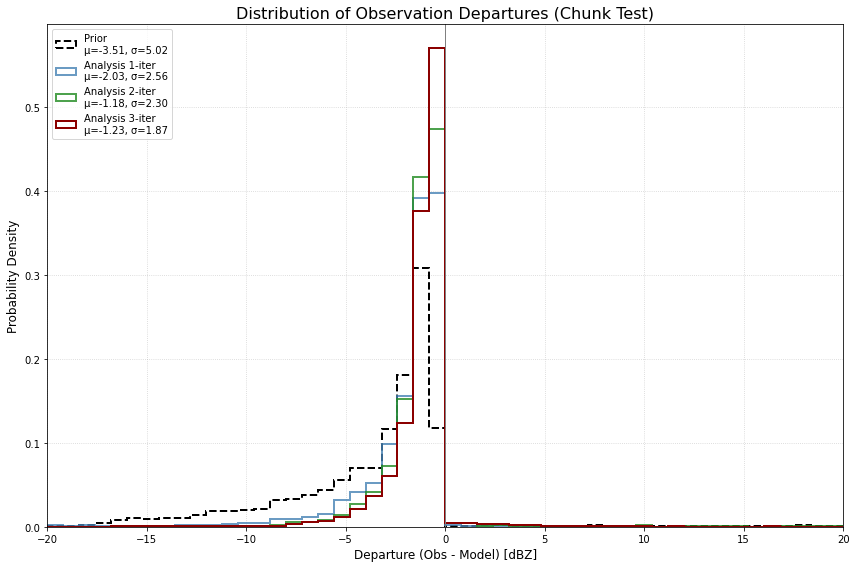

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

#----------------------------------------------------------------------
## 1. USER CONFIGURATION
#----------------------------------------------------------------------
# ❗ Update this to match your actual output directory and experiment tag
base_path = "/home/jorge.gacitua/salidas/WRF_Single_Cycle_Assimilation/data/WS1_chunks/"
tag = "WS1_chunks"  
truth_member = "00"

# List the specific chunks you have ready
chunk_numbers = [1, 3, 4, 6,7,9,10,12,13,14,16,18,20,21]

# Plotting parameters
hist_bins = 50
hist_range = (-20, 20) # Plotting range for departures (dBZ)

#----------------------------------------------------------------------
## 2. LOAD AND COMBINE DATA
#----------------------------------------------------------------------
print("Loading chunk files...")
all_data = []

for cid in chunk_numbers:
    # Format: EXP_fullgrid_chunk0001_True00.npy
    fname = f"{tag}_fullgrid_chunk{cid:04d}_True{truth_member}.npy"
    filepath = os.path.join(base_path, fname)
    
    if os.path.exists(filepath):
        print(f"  -> Loading {fname}")
        chunk_data = np.load(filepath, allow_pickle=True)
        all_data.extend(chunk_data)
    else:
        print(f"  -> [WARNING] File not found: {filepath}")

# Convert to Pandas DataFrame for incredibly easy filtering
df = pd.DataFrame(all_data)
print(f"Data loaded. Found {len(df) // 3} unique observations (across 3 iterations).")

#----------------------------------------------------------------------
## 3. EXTRACT DEPARTURES
#----------------------------------------------------------------------
# Filter down to just the TEnKF method
df_tenkf = df[df['method'] == 'TEnKF']

# Separate the DataFrame by iteration
df_1 = df_tenkf[df_tenkf['ntemp'] == 1]
df_2 = df_tenkf[df_tenkf['ntemp'] == 2]
df_3 = df_tenkf[df_tenkf['ntemp'] == 3]

# The prior departure (O-B) is identical across iterations for the same point, 
# so we just take it from the 1-iteration dataset.
deps_prior = df_1['dep_b'].values

# The analysis departures (O-A)
deps_1 = df_1['dep_a'].values
deps_2 = df_2['dep_a'].values
deps_3 = df_3['dep_a'].values

print("Departures extracted successfully.")

#----------------------------------------------------------------------
## 4. CREATE THE PLOT
#----------------------------------------------------------------------
print("Generating plot...")

fig, ax = plt.subplots(figsize=(12, 8))

# Plot as density histograms
ax.hist(deps_prior, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Prior \nμ={deps_prior.mean():.2f}, σ={deps_prior.std():.2f}', 
        color='black', linestyle='--')

ax.hist(deps_1, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 1-iter \nμ={deps_1.mean():.2f}, σ={deps_1.std():.2f}', 
        color='SteelBlue', alpha=0.8)

ax.hist(deps_2, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2,
        label=f'Analysis 2-iter \nμ={deps_2.mean():.2f}, σ={deps_2.std():.2f}', 
        color='ForestGreen', alpha=0.8)

ax.hist(deps_3, bins=hist_bins, range=hist_range, 
        density=True, histtype='step', linewidth=2, 
        label=f'Analysis 3-iter \nμ={deps_3.mean():.2f}, σ={deps_3.std():.2f}', 
        color='DarkRed', alpha=1.0)

# --- Formatting ---
ax.set_title('Distribution of Observation Departures (Chunk Test)', fontsize=16)
ax.set_xlabel('Departure (Obs - Model) [dBZ]', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(hist_range) 

# Add a vertical line at zero
ax.axvline(0, color='gray', linestyle='-', linewidth=1)

plt.tight_layout()
plt.show()

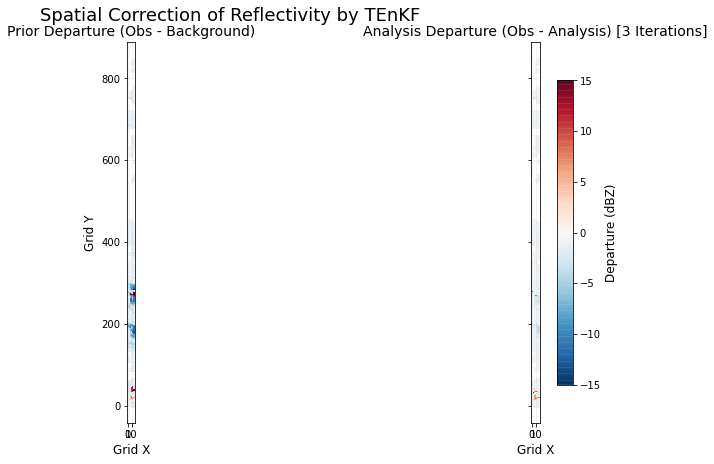

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select the data for the final iteration (3 steps)
df_plot = df_tenkf[df_tenkf['ntemp'] == 3].copy()

# Optional: If you have multiple vertical levels in your chunks, 
# it is usually best to plot one level at a time (e.g., z=4) to avoid overlapping dots.
# df_plot = df_plot[df_plot['obs_z'] == 4]

# 2. Set up a diverging colormap centered at zero
# Red = Positive departure (Model underestimated)
# Blue = Negative departure (Model overestimated)
cmap = 'RdBu_r'
vmin, vmax = -15, 15  # Limit the color scale to +/- 15 dBZ for contrast

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# --- Plot 1: Prior Departure (O-B) ---
sc1 = axes[0].scatter(df_plot['obs_x'], df_plot['obs_y'], 
                      c=df_plot['dep_b'], cmap=cmap, vmin=vmin, vmax=vmax, 
                      s=15, marker='s', alpha=0.9)
axes[0].set_title('Prior Departure (Obs - Background)', fontsize=14)
axes[0].set_xlabel('Grid X', fontsize=12)
axes[0].set_ylabel('Grid Y', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.5)

# --- Plot 2: Analysis Departure (O-A) ---
sc2 = axes[1].scatter(df_plot['obs_x'], df_plot['obs_y'], 
                      c=df_plot['dep_a'], cmap=cmap, vmin=vmin, vmax=vmax, 
                      s=15, marker='s', alpha=0.9)
axes[1].set_title('Analysis Departure (Obs - Analysis) [3 Iterations]', fontsize=14)
axes[1].set_xlabel('Grid X', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.5)

# Add a single colorbar for both plots
cbar = fig.colorbar(sc2, ax=axes.ravel().tolist(), pad=0.02, shrink=0.8)
cbar.set_label('Departure (dBZ)', fontsize=12)

# Keep the aspect ratio square since it's a physical map
axes[0].set_aspect('equal')
axes[1].set_aspect('equal')

plt.suptitle('Spatial Correction of Reflectivity by TEnKF', fontsize=18, y=0.95)
plt.show()

In [3]:
np.nanmax(df_plot['obs_y'])

760

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

file = "/home/jorge.gacitua/salidas/WRF_Single_Cycle_Assimilation/data/WS1_chunks/WS1_chunks_fullgrid_chunk0001_True00.npy"
data = np.load(file, allow_pickle=True)
df = pd.DataFrame(data)
print(f"Files in the npz file: {data.files}")
print(f"Shapes of the arrays:")
for key in data.files:
    print(f"  {key}: {data[key].shape}")

AttributeError: 'numpy.ndarray' object has no attribute 'files'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/ws1_below"

# Define file paths
file_paths = {
    'LETKF'   : f'{path}/WS1_Ntemp_sweep_TEnKF_Nt01_as2_Lx5Ly5Lz1_Ne020_obs84_108_5_qcE_True00.npz',
    'LETKF-T2': f'{path}/WS1_Ntemp_sweep_TEnKF_Nt02_as2_Lx5Ly5Lz1_Ne020_obs84_108_5_qcE_True00.npz',
    'LETKF-T3': f'{path}/WS1_Ntemp_sweep_TEnKF_Nt03_as2_Lx5Ly5Lz1_Ne020_obs84_108_5_qcE_True00.npz'
}

for method, file in file_paths.items():
    data = np.load(file)
    ox = data['ox']
    oy = data['oy']
    oz = data['oz']
    yo = data['yo']
    fmean = data['hxf_mean']
    fdep = data['dep']
    fspread = data['spread']
    amean = np.nanmean(data['xa'][ox, oy, oz, :, 0]*1000)
    adep = (amean - yo)
    print(f"Method: {method}\n obs {yo}\n prior Mean {fmean}\n prior departure {fdep}\n prior spread {fspread}\n analysis mean {amean}\n analysis departure {adep}")


Method: LETKF
 obs [-20.]
 prior Mean [-9.63016]
 prior departure [-10.36984]
 prior spread [15.427087]
 analysis mean 0.00010227598249912262
 analysis departure [20.000103]
Method: LETKF-T2
 obs [-20.]
 prior Mean [-9.63016]
 prior departure [-10.36984]
 prior spread [15.427087]
 analysis mean -0.0001806693326216191
 analysis departure [19.999819]
Method: LETKF-T3
 obs [-20.]
 prior Mean [-9.63016]
 prior departure [-10.36984]
 prior spread [15.427087]
 analysis mean -0.00032449880382046103
 analysis departure [19.999676]


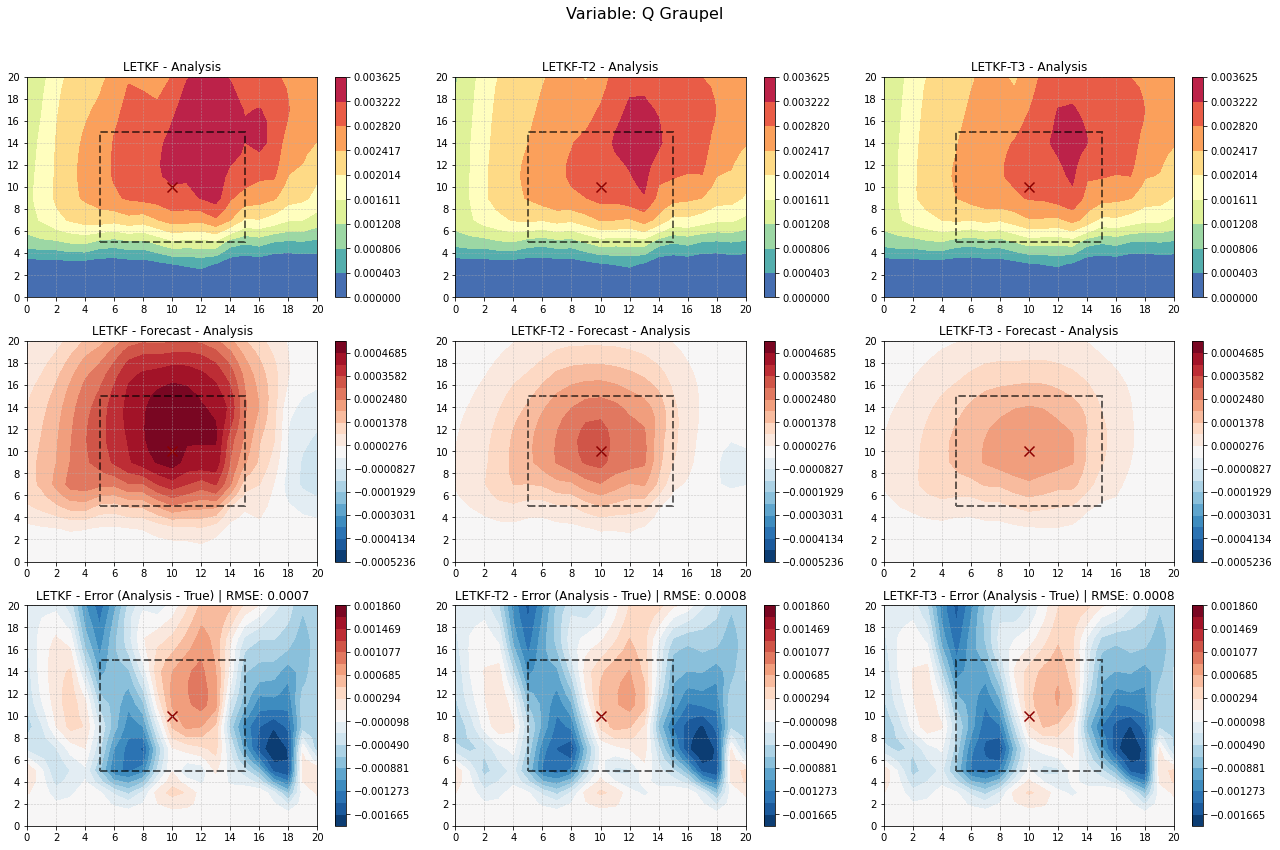

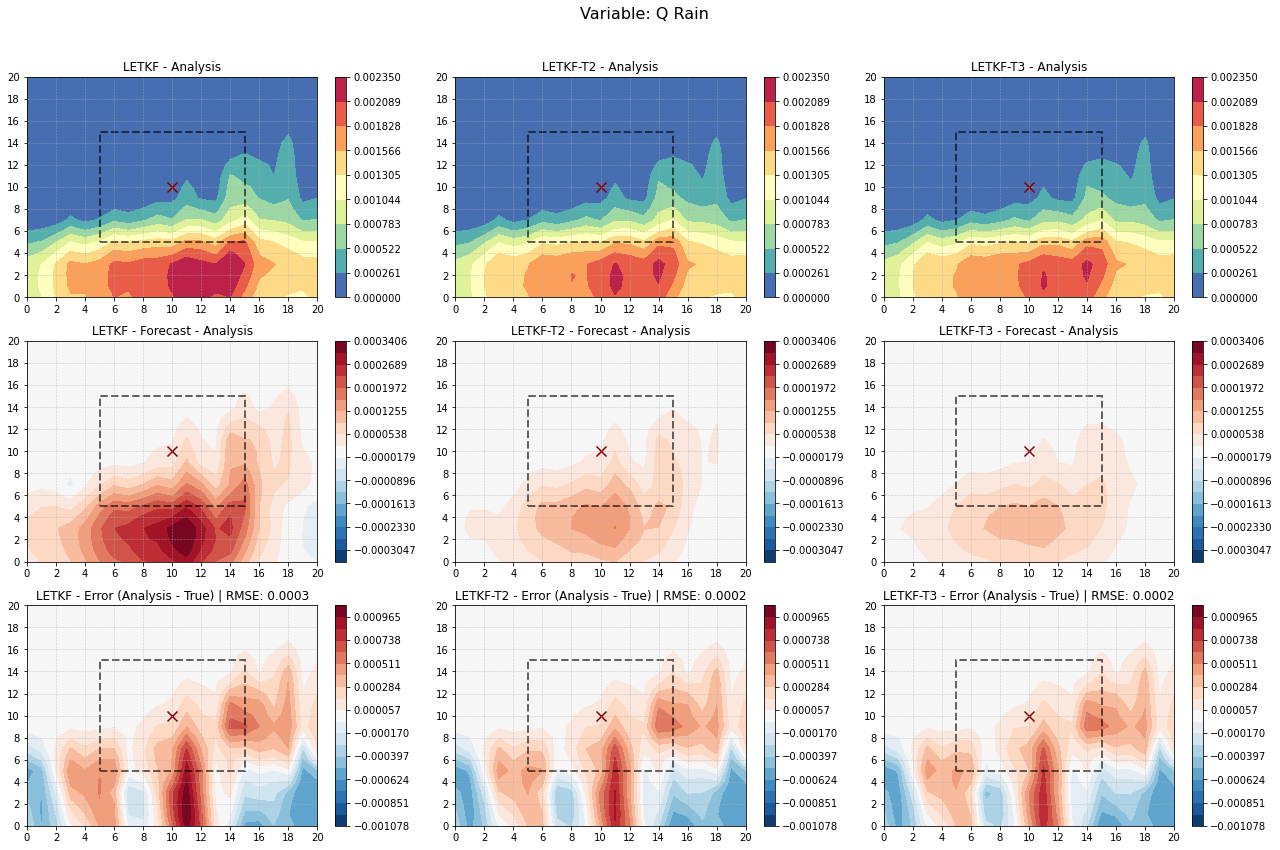

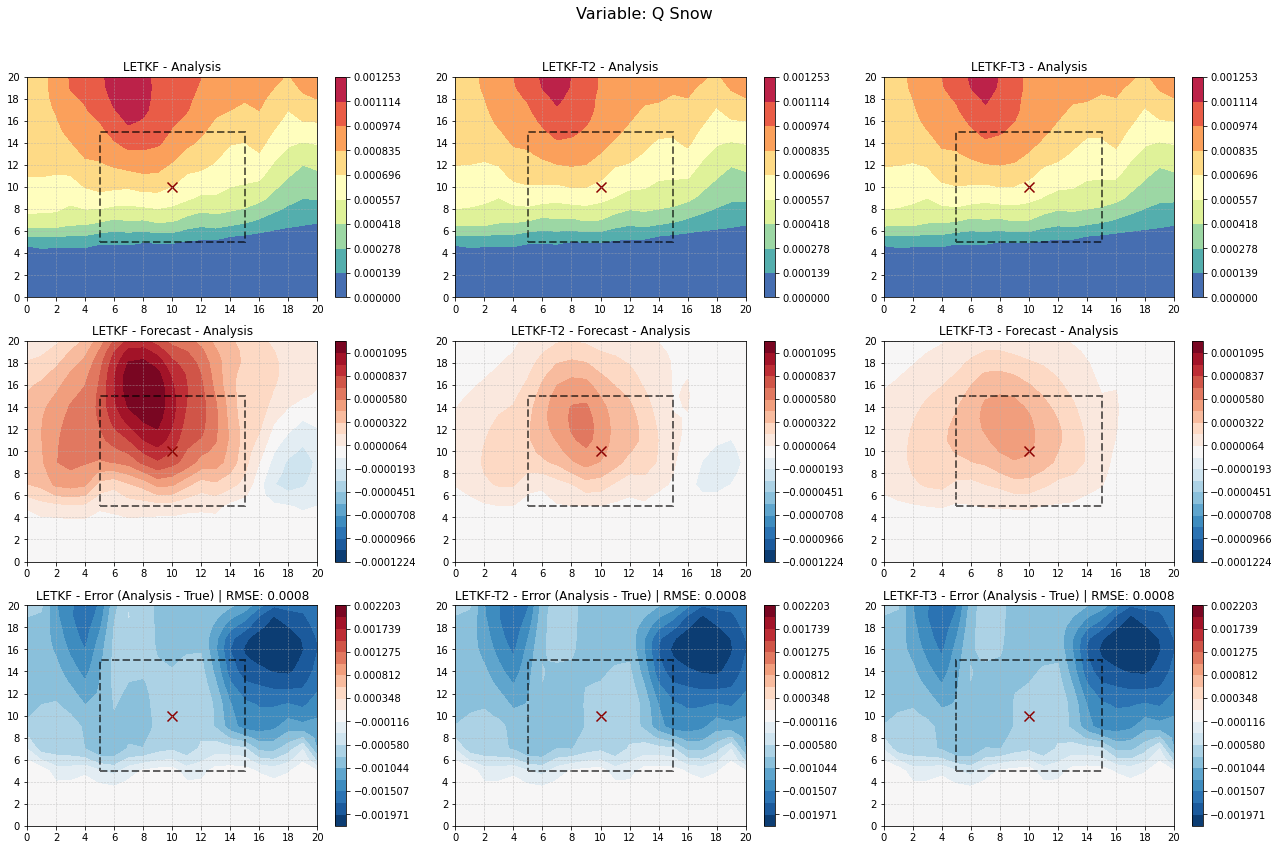

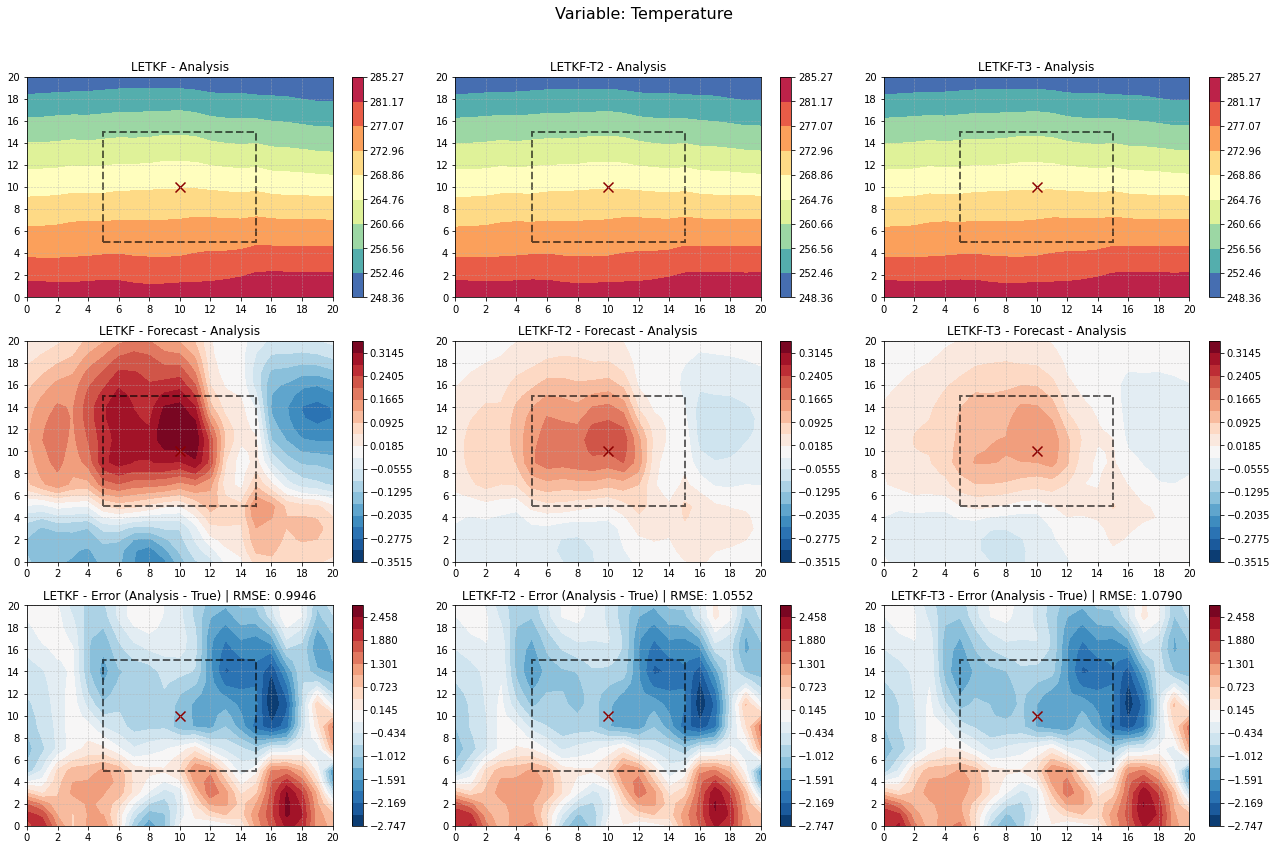

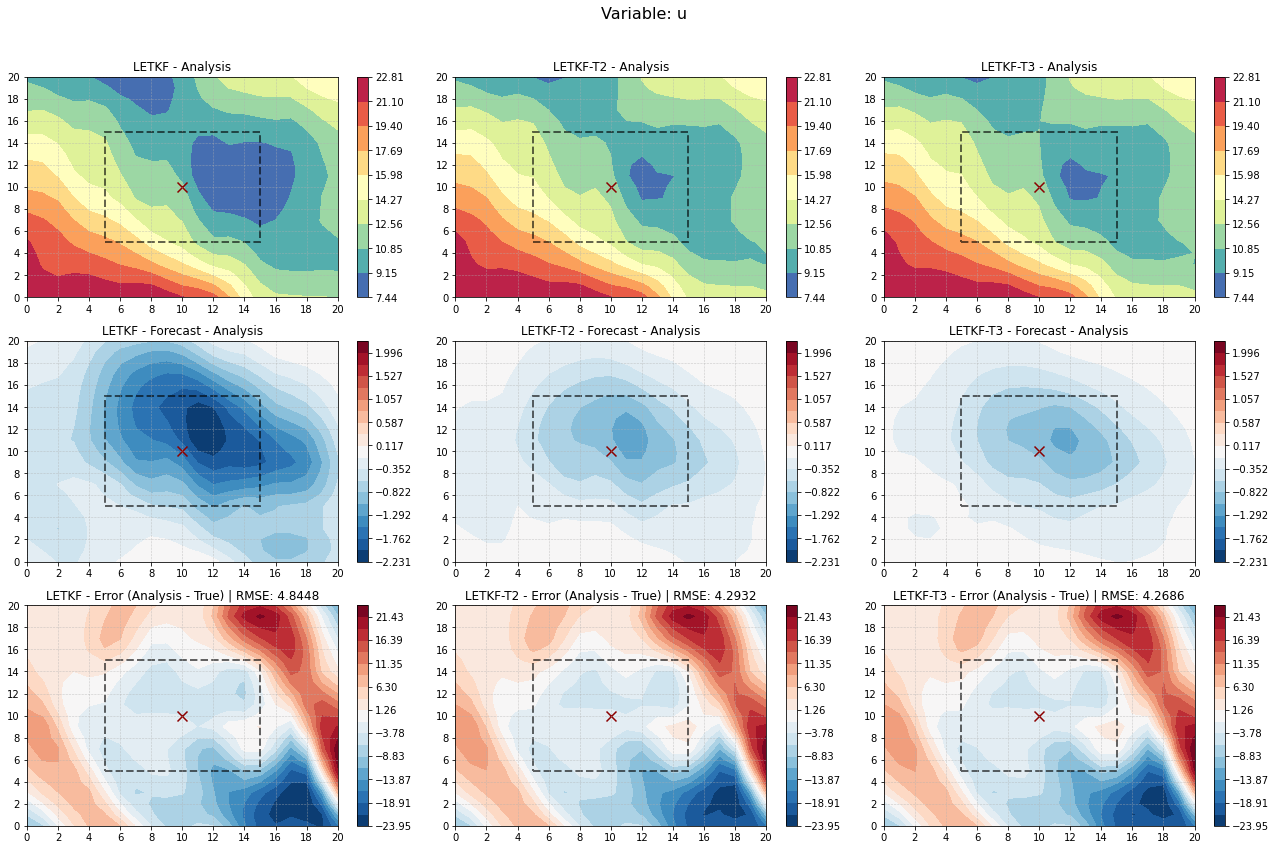

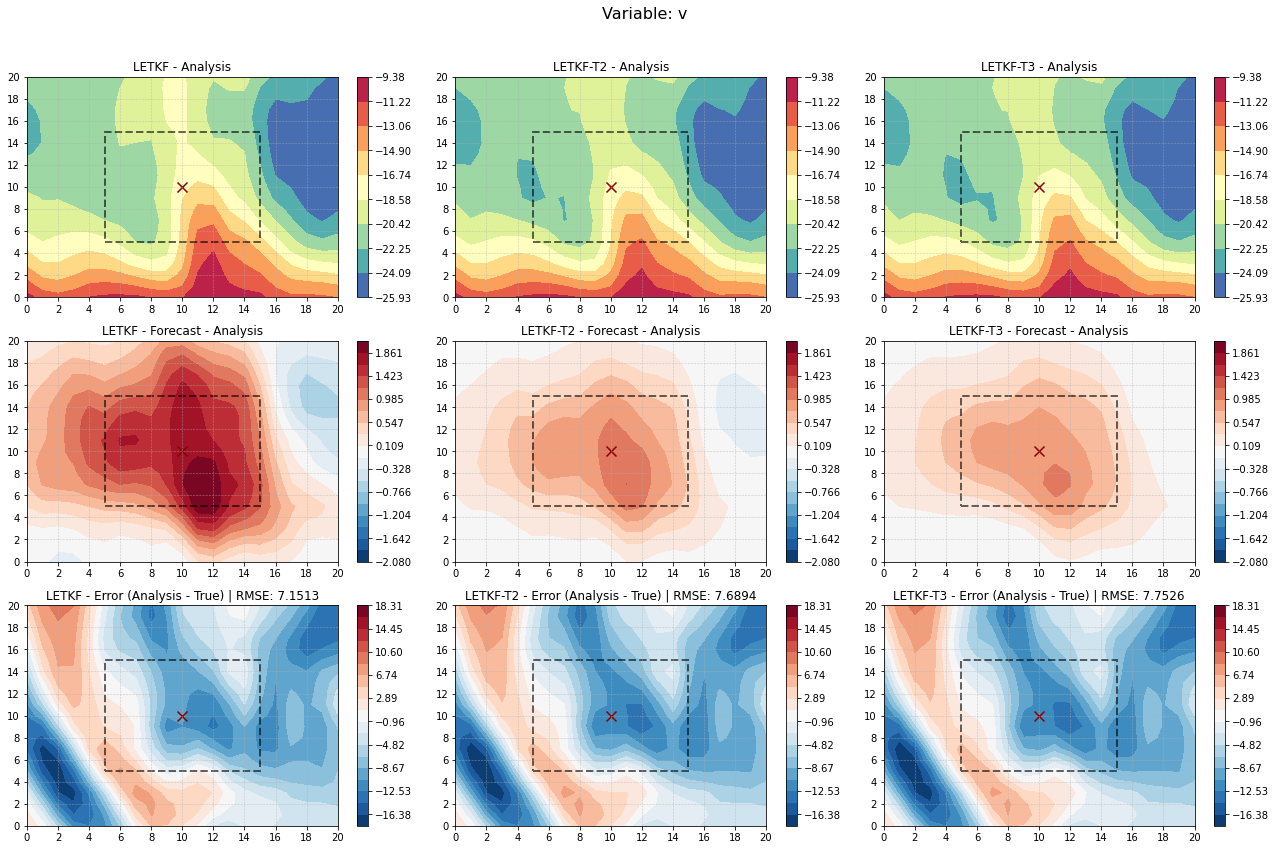

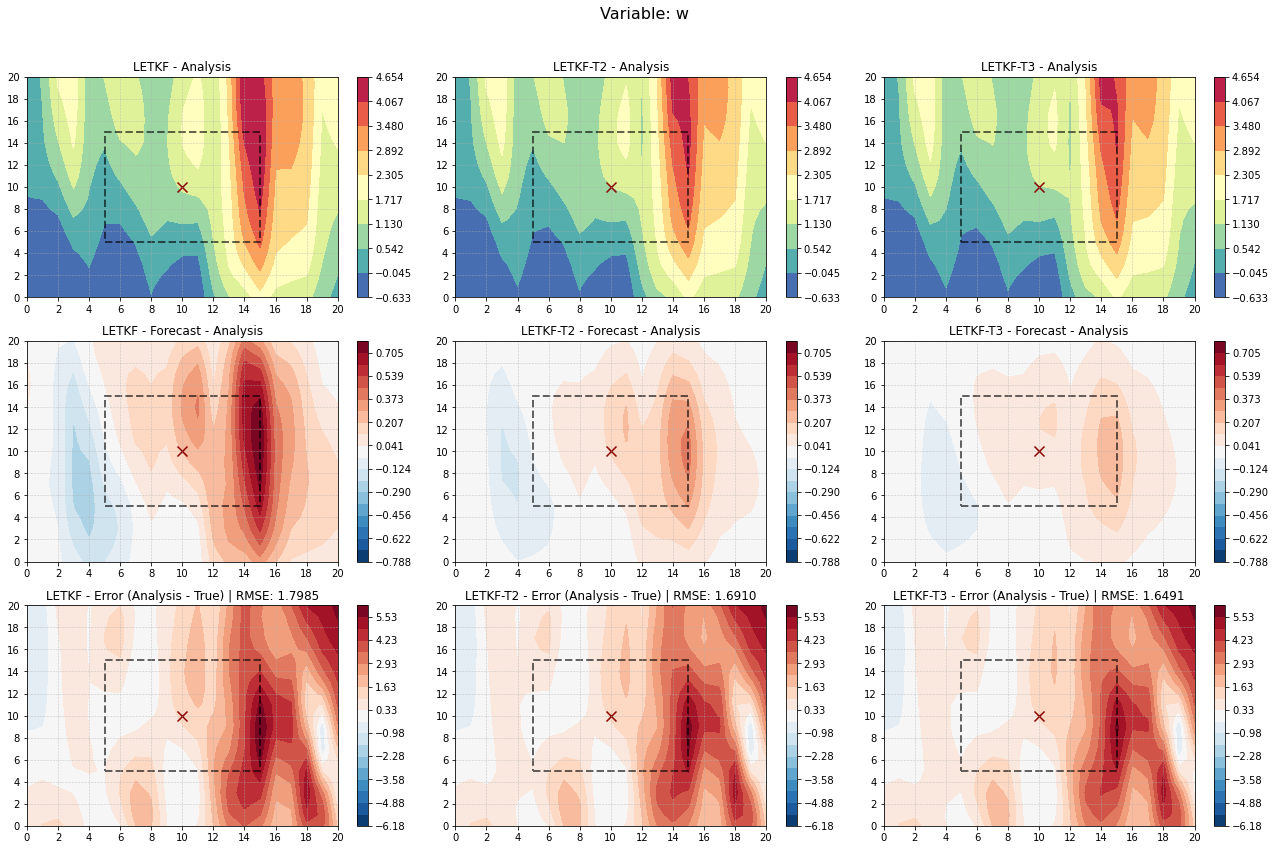

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosmunin/WRF_Single_Cycle_Assimilation/data/ws1_below"

# Define file paths
file_paths = {
    'LETKF'   : f'{path}/WS1_Ntemp_sweep_TEnKF_Nt01_as2_Lx5Ly5Lz1_Ne020_obs84_108_5_qcE_True00.npz',
    'LETKF-T2': f'{path}/WS1_Ntemp_sweep_TEnKF_Nt02_as2_Lx5Ly5Lz1_Ne020_obs84_108_5_qcE_True00.npz',
    'LETKF-T3': f'{path}/WS1_Ntemp_sweep_TEnKF_Nt03_as2_Lx5Ly5Lz1_Ne020_obs84_108_5_qcE_True00.npz'
}

# Variable names
variables = {
    0: 'Q Graupel',
    1: 'Q Rain',
    2: 'Q Snow',
    3: 'Temperature',
    5: 'u',
    6: 'v',
    7: 'w'
}

r_loc = 5  # Localization radius

for var_index, var_name in variables.items():
    ncols = len(file_paths)
    fig, axs = plt.subplots(3, ncols, figsize=(6 * ncols, 12))

    contour_levels = {}  # Store contour levels and ticks per row
    vmin_fields = []
    vmax_fields = []
    diff_maxs = []
    err_maxs = []

    for col_index, (col_name, file_path) in enumerate(file_paths.items()):
        data = np.load(file_path)

        obs_loc_x = data['obs_loc'][0]
        obs_loc_z = data['obs_loc'][2]

        x_start, x_end = obs_loc_x - 2 * r_loc, obs_loc_x + 2 * r_loc + 1
        z_start, z_end = obs_loc_z - 2 * r_loc, obs_loc_z + 2 * r_loc + 1

        xa = data['xatemp'][x_start:x_end, 0, z_start:z_end, :, :, -1]
        xf = data['xf'][x_start:x_end, 0, z_start:z_end, :, :]
        true_state = data['truth'][x_start:x_end, 0, z_start:z_end, :]

        mean_xa = np.mean(xa, axis=2)
        mean_xf = np.mean(xf, axis=2)

        forecast_field = mean_xf[:, :, var_index]
        analysis_field = mean_xa[:, :, var_index]
        true_field = true_state[:, :, var_index]

        diff_forecast_analysis = forecast_field - analysis_field
        error_analysis = analysis_field - true_field

        vmin_fields.append(np.nanmin(analysis_field))
        vmax_fields.append(np.nanmax(analysis_field))
        diff_maxs.append(np.nanmax(np.abs(diff_forecast_analysis)))
        err_maxs.append(np.nanmax(np.abs(error_analysis)))


    vmin_field=np.nanmin(vmin_fields)
    vmax_field=np.nanmax(vmax_fields)
    contour_levels['field'] = np.linspace(vmin_field, vmax_field, 10)

    diff_max = np.nanmax(diff_maxs)
    contour_levels['diff'] = np.linspace(-diff_max, diff_max, 20)

    err_max = np.nanmax(err_maxs)
    contour_levels['error'] = np.linspace(-err_max, err_max, 20)

    for col_index, (col_name, file_path) in enumerate(file_paths.items()):
        data = np.load(file_path)

        obs_loc_x = data['obs_loc'][0]
        obs_loc_z = data['obs_loc'][2]

        x_start, x_end = obs_loc_x - 2 * r_loc, obs_loc_x + 2 * r_loc + 1
        z_start, z_end = obs_loc_z - 2 * r_loc, obs_loc_z + 2 * r_loc + 1

        xa = data['xatemp'][x_start:x_end, 0, z_start:z_end, :, :, -1]
        xf = data['xf'][x_start:x_end, 0, z_start:z_end, :, :]
        true_state = data['truth'][x_start:x_end, 0, z_start:z_end, :]

        mean_xa = np.mean(xa, axis=2)
        mean_xf = np.mean(xf, axis=2)

        forecast_field = mean_xf[:, :, var_index]
        analysis_field = mean_xa[:, :, var_index]
        true_field = true_state[:, :, var_index]

        diff_forecast_analysis = analysis_field - forecast_field
        error_analysis = analysis_field - true_field

        # Forecast
        im0 = axs[0, col_index].contourf(analysis_field.T, cmap='Spectral_r', levels=contour_levels['field'])
        cb0 = fig.colorbar(im0, ax=axs[0, col_index])
        axs[0, col_index].set_title(f"{col_name} - Analysis")

        # Forecast - Analysis Difference
        im1 = axs[1, col_index].contourf(diff_forecast_analysis.T, cmap='RdBu_r', levels=contour_levels['diff'])
        cb1 = fig.colorbar(im1, ax=axs[1, col_index])
        axs[1, col_index].set_title(f"{col_name} - Forecast - Analysis")

        # Compute RMSE inside the square
        square_x_start, square_x_end = 2 * r_loc - r_loc, 2 * r_loc + r_loc
        square_z_start, square_z_end = 2 * r_loc - r_loc, 2 * r_loc + r_loc
        square_error = error_analysis[square_x_start:square_x_end, square_z_start:square_z_end]
        rmse = np.sqrt(np.nanmean(square_error**2))

        # Analysis Error
        im2 = axs[2, col_index].contourf(error_analysis.T, cmap='RdBu_r', levels=contour_levels['error'])
        cb2 = fig.colorbar(im2, ax=axs[2, col_index])
        axs[2, col_index].set_title(f"{col_name} - Error (Analysis - True) | RMSE: {rmse:.4f}")

        # Grid every 2 units and add square
        for ax in axs[:, col_index]:
            ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
            ax.set_xticks(np.arange(0, forecast_field.shape[0], 2))
            ax.set_yticks(np.arange(0, forecast_field.shape[1], 2))

            # Scatter point
            ax.scatter(2 * r_loc, 2 * r_loc, color="DarkRed", marker='x', s=100)

            # Square region
            rect = plt.Rectangle((2 * r_loc - r_loc, 2 * r_loc - r_loc), 2 * r_loc, 2 * r_loc,
                                 linewidth=2, edgecolor='black', facecolor='none', linestyle='--', alpha=0.6)
            ax.add_patch(rect)

    # General title
    fig.suptitle(f"Variable: {var_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()